# Budget Phasing Walkthrough

Notebook 01 showed the problem: when TV, Meta, and Search spend are all correlated, OLS elasticity estimates are unreliable. The same market gives wildly different answers depending on which period of data you happened to use.

This notebook shows the fix. `BudgetPhaser` takes your 52-week spend plan and finds the optimal amount of independent weekly variation to introduce into the channel mix — while keeping monthly budgets intact. The output is a concrete week-by-week schedule you can hand to your media agency.


In [1]:
FAST_MODE = False  # set False for publication-quality runs

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from how_wrong_is_your_mmm import CollinearityDiagnostic, BudgetPhaser, simulate_spend


## The starting point

We simulate a year of weekly spend (52 weeks) with a realistic correlation of 0.7 across all three channels. The `start_date` gives us a proper DatetimeIndex — required by `BudgetPhaser` so it knows which weeks belong to which month.


In [3]:
spend = simulate_spend(n_obs=52, correlation=0.7, seed=0, start_date='2023-01-02')
print(f'Spend: {spend.shape[0]} weeks, {spend.shape[1]} channels')
print(f'Date range: {spend.index[0].date()} to {spend.index[-1].date()}')
print()
for ch in spend.columns:
    print(f'{ch.upper():6s}  mean weekly: £{spend[ch].mean():,.0f}  annual: £{spend[ch].sum():,.0f}')
print()
print('Correlation matrix:')
print(spend.corr().round(2))


Spend: 52 weeks, 3 channels
Date range: 2023-01-02 to 2023-12-25

TV      mean weekly: £102,849  annual: £5,348,174
META    mean weekly: £81,243  annual: £4,224,611
SEARCH  mean weekly: £60,342  annual: £3,137,771

Correlation matrix:
          tv  meta  search
tv      1.00  0.58    0.61
meta    0.58  1.00    0.75
search  0.61  0.75    1.00


## Baseline unreliability

Before recommending any changes, we establish how unreliable the current plan is. This is the number we're trying to reduce.


In [4]:
n_sims = 10 if FAST_MODE else 50

baseline = CollinearityDiagnostic(
    spend_df=spend,
    true_elasticities={'tv': 0.3, 'meta': 0.5, 'search': 0.4},
)
baseline.fit(n_sims=n_sims, fast_mode=FAST_MODE)
print('Baseline (no phasing):')
print(baseline.summary().to_string(index=False))


Baseline (no phasing):
channel  true_elasticity  mean_estimated  std_estimated  mean_error_pct  coef_of_variation
   meta              0.5          0.5471         0.2738          9.4254             0.5005
 search              0.4          0.4085         0.3376          2.1350             0.8264
     tv              0.3          0.2898         0.1978         -3.4016             0.6827


## Running BudgetPhaser

The phaser grid-searches over a phasing amplitude α ∈ [0, 1]:

- **α = 0** — no change from original plan
- **α = 1** — maximum allowed weekly deviation (40% per channel by default)

For each α it generates a phased schedule — redistributing each channel's weekly spend within each month, keeping monthly totals exactly intact — then runs `CollinearityDiagnostic` to measure the resulting elasticity reliability.


In [5]:
grid_steps = 10 if FAST_MODE else 20

phaser = BudgetPhaser(
    spend_df=spend,
    true_elasticities={'tv': 0.3, 'meta': 0.5, 'search': 0.4},
    max_weekly_deviation_pct=40.0,
)
phaser.fit(n_sims=n_sims, grid_steps=grid_steps, fast_mode=FAST_MODE)
print(phaser.summary().to_string(index=False))


 alpha  actual_correlation  max_cv  max_monthly_deviation_pct  cv_tv  cv_meta  cv_search
0.0000              0.6490  0.8264                        0.0 0.6827   0.5005     0.8264
0.0526              0.6481  0.8287                        0.0 0.6740   0.4830     0.8287
0.1053              0.6401  0.7908                        0.0 0.6750   0.4700     0.7908
0.1579              0.6068  0.8292                        0.0 0.6215   0.5387     0.8292
0.2105              0.6139  0.6847                        0.0 0.6448   0.4504     0.6847
0.2632              0.6546  0.7063                        0.0 0.6414   0.4990     0.7063
0.3158              0.5750  0.6674                        0.0 0.5593   0.4163     0.6674
0.3684              0.5978  0.6577                        0.0 0.5919   0.4997     0.6577
0.4211              0.5624  0.7708                        0.0 0.5559   0.5137     0.7708
0.4737              0.5351  0.7456                        0.0 0.5219   0.3845     0.7456
0.5263              0

## The CV curve

The chart shows how elasticity reliability (max CV across channels) and inter-channel correlation change as phasing amplitude increases. The green dashed line marks the recommended α.


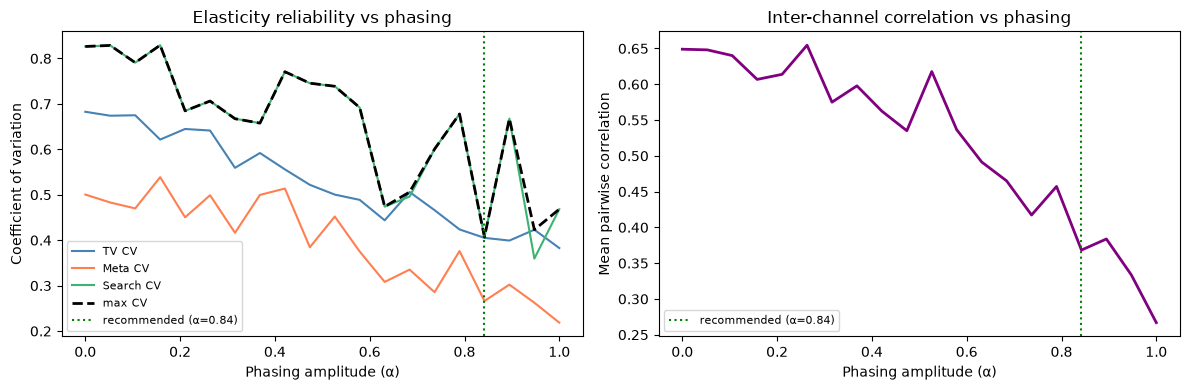

In [6]:
results = phaser.summary()
rec = phaser.recommend()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(results['alpha'], results['cv_tv'], color='steelblue', label='TV CV')
ax.plot(results['alpha'], results['cv_meta'], color='coral', label='Meta CV')
ax.plot(results['alpha'], results['cv_search'], color='mediumseagreen', label='Search CV')
ax.plot(results['alpha'], results['max_cv'], color='black', linewidth=2,
        linestyle='--', label='max CV')
ax.axvline(rec['alpha'], color='green', linestyle=':', linewidth=1.5,
           label=f"recommended (α={rec['alpha']:.2f})")
ax.set_xlabel('Phasing amplitude (α)')
ax.set_ylabel('Coefficient of variation')
ax.set_title('Elasticity reliability vs phasing')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(results['alpha'], results['actual_correlation'], color='purple', linewidth=2)
ax.axvline(rec['alpha'], color='green', linestyle=':', linewidth=1.5,
           label=f"recommended (α={rec['alpha']:.2f})")
ax.set_xlabel('Phasing amplitude (α)')
ax.set_ylabel('Mean pairwise correlation')
ax.set_title('Inter-channel correlation vs phasing')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## How phasing affects elasticity estimates

Abstract metrics like CV are useful, but this chart makes the improvement tangible. We run `CollinearityDiagnostic` at three phasing levels — no phasing (α=0), the recommended α, and maximum phasing (α=1) — and plot the distribution of estimated elasticities across simulation seeds. The true elasticity is shown as a dashed horizontal line.

Narrower spread = more reliable model.

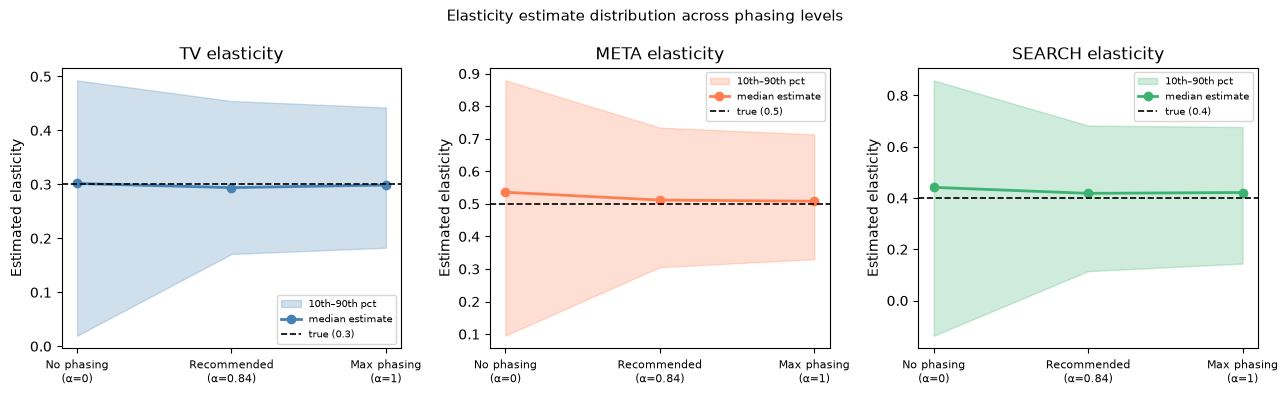

In [7]:
# run CollinearityDiagnostic at three phasing levels to get raw elasticity distributions
from how_wrong_is_your_mmm._phaser import _generate_phased_schedule, _get_month_labels

month_labels = _get_month_labels(spend)
true_elasticities = {'tv': 0.3, 'meta': 0.5, 'search': 0.4}
best_alpha = phaser.recommend()['alpha']

alpha_levels = {
    f'No phasing\n(α=0)': 0.0,
    f'Recommended\n(α={best_alpha:.2f})': best_alpha,
    f'Max phasing\n(α=1)': 1.0,
}

# collect raw per-seed elasticity estimates for each alpha
elast_data = {}  # alpha_label -> {channel -> array of estimates}
for label, alpha in alpha_levels.items():
    phased = _generate_phased_schedule(
        spend, month_labels, alpha=alpha,
        max_weekly_deviation_pct=phaser.max_weekly_deviation_pct, seed=99
    )
    diag = CollinearityDiagnostic(spend_df=phased, true_elasticities=true_elasticities)
    diag.fit(n_sims=n_sims)
    channel_estimates = {}
    for ch in spend.columns:
        channel_estimates[ch] = diag.results_[
            diag.results_['channel'] == ch
        ]['estimated_elasticity'].to_numpy()
    elast_data[label] = channel_estimates

# plot: one panel per channel, x = alpha level, fan = 10th-90th pct, line = median
channel_colors = {'tv': 'steelblue', 'meta': 'coral', 'search': 'mediumseagreen'}
labels = list(alpha_levels.keys())
x = range(len(labels))

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

for ax, ch in zip(axes, spend.columns):
    color = channel_colors[ch]
    true_val = true_elasticities[ch]

    medians = []
    p10s = []
    p90s = []
    for label in labels:
        estimates = elast_data[label][ch]
        medians.append(float(np.median(estimates)))
        p10s.append(float(np.percentile(estimates, 10)))
        p90s.append(float(np.percentile(estimates, 90)))

    ax.fill_between(x, p10s, p90s, alpha=0.25, color=color, label='10th–90th pct')
    ax.plot(x, medians, color=color, linewidth=2, marker='o', label='median estimate')
    ax.axhline(true_val, color='black', linestyle='--', linewidth=1.2, label=f'true ({true_val})')
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f'{ch.upper()} elasticity')
    ax.set_ylabel('Estimated elasticity')
    ax.legend(fontsize=7)

plt.suptitle('Elasticity estimate distribution across phasing levels', fontsize=11)
plt.tight_layout()
plt.show()


## The recommendation


In [8]:
rec = phaser.recommend()
baseline_cv = phaser.summary()['max_cv'].iloc[0]
cv_reduction = 100 * (baseline_cv - rec['max_cv']) / baseline_cv
max_dev_pct = phaser.max_weekly_deviation_pct * rec['alpha']

print('Recommendation')
print('=' * 55)
print(f"Phasing amplitude:        α = {rec['alpha']:.2f}")
print(f"Max channel weekly deviation:  ±{max_dev_pct:.0f}% of original weekly spend")
print()
print(f"Mean pairwise correlation:  {spend.corr().to_numpy()[[0,0,1],[1,2,2]].mean():.2f} → {rec['actual_correlation']:.2f}")
print(f"Max CV:                     {baseline_cv:.3f} → {rec['max_cv']:.3f}")
print(f"CV reduction:               {cv_reduction:.0f}%")


Recommendation
Phasing amplitude:        α = 0.84
Max channel weekly deviation:  ±34% of original weekly spend

Mean pairwise correlation:  0.65 → 0.37
Max CV:                     0.826 → 0.407
CV reduction:               51%


## The recommended schedule

The recommended schedule is a concrete 52-week spend plan. Monthly totals are preserved exactly — the only change is how the budget is paced week-to-week within each month.


In [9]:
sched = phaser.recommended_schedule_

# compare monthly totals — should be identical
orig_monthly = spend.resample('ME').sum().round(0)
new_monthly = sched.resample('ME').sum().round(0)

print('Monthly totals — original vs recommended (£):')
print()
for ch in spend.columns:
    print(f'{ch.upper()}')
    comparison = pd.DataFrame({'original': orig_monthly[ch], 'recommended': new_monthly[ch]})
    comparison['difference'] = comparison['recommended'] - comparison['original']
    print(comparison.to_string())
    print()


Monthly totals — original vs recommended (£):

TV
            original  recommended  difference
2023-01-31  506536.0     506536.0         0.0
2023-02-28  417410.0     417410.0         0.0
2023-03-31  321824.0     321824.0         0.0
2023-04-30  388103.0     388103.0         0.0
2023-05-31  533352.0     533352.0         0.0
2023-06-30  423824.0     423824.0         0.0
2023-07-31  457847.0     457847.0         0.0
2023-08-31  392590.0     392590.0         0.0
2023-09-30  432541.0     432541.0         0.0
2023-10-31  599602.0     599602.0         0.0
2023-11-30  425907.0     425907.0         0.0
2023-12-31  448638.0     448638.0         0.0

META
            original  recommended  difference
2023-01-31  376049.0     376049.0         0.0
2023-02-28  347046.0     347046.0         0.0
2023-03-31  272722.0     272722.0         0.0
2023-04-30  313470.0     313470.0         0.0
2023-05-31  421774.0     421774.0         0.0
2023-06-30  303128.0     303128.0         0.0
2023-07-31  365080.0    

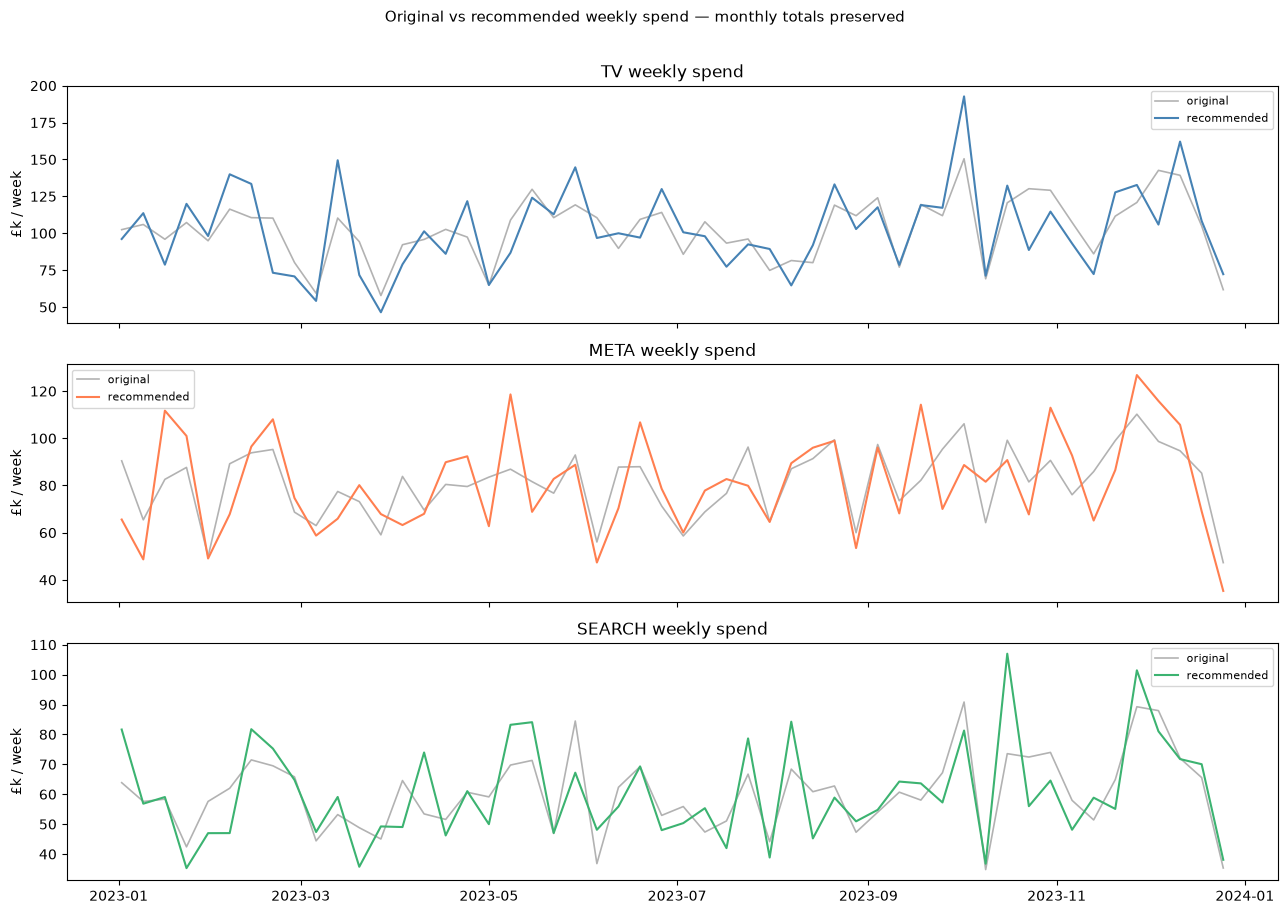

In [10]:
# plot weekly spend — original vs recommended for each channel
channels_cfg = [
    ('tv',     'steelblue'),
    ('meta',   'coral'),
    ('search', 'mediumseagreen'),
]

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

for ax, (ch, color) in zip(axes, channels_cfg):
    ax.plot(spend.index, spend[ch] / 1000, color='grey', alpha=0.6,
            linewidth=1.2, label='original')
    ax.plot(sched.index, sched[ch] / 1000, color=color, linewidth=1.5,
            label='recommended')
    ax.set_ylabel('£k / week')
    ax.set_title(f'{ch.upper()} weekly spend')
    ax.legend(fontsize=8)

plt.suptitle('Original vs recommended weekly spend — monthly totals preserved',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


## What this achieves

The recommended schedule introduces independent variation in the weekly channel mix — some weeks TV gets a larger share of its monthly budget, others less — while Meta and Search follow their own independent patterns. This de-correlates the channels without changing annual or monthly commitments.

After accumulating enough weeks of this data, the MMM has the variation it needs to reliably distinguish individual channel effects. `CollinearityWeighter` (next sprint) speeds this up further by upweighting the most informative (low-collinearity) periods in the model fit.
